In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv(r"C:\Users\kpswe\Downloads\walmart_data.txt")
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [3]:
df.isna().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

In [4]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [5]:
df.drop_duplicates(inplace=True)

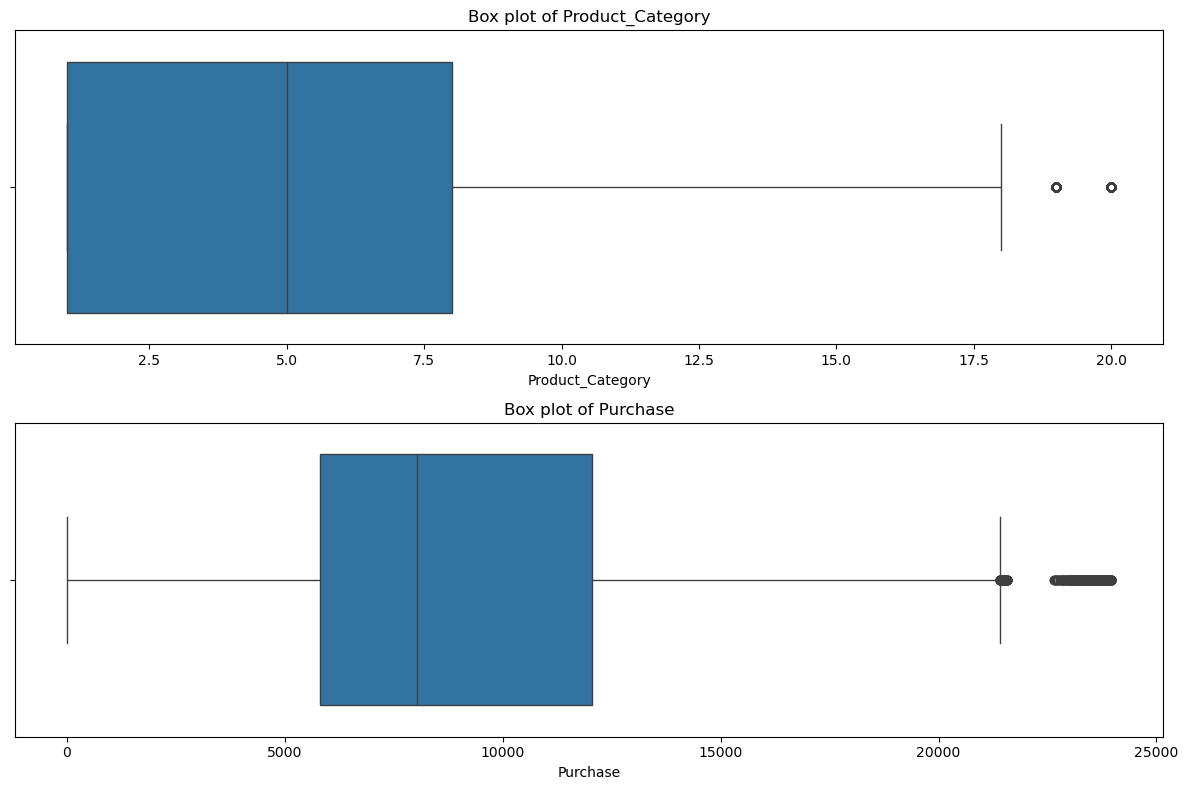

In [6]:
numerical_cols = ["Product_Category", "Purchase"]

# Create box plots
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 1, i)
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')

plt.tight_layout()
plt.show()

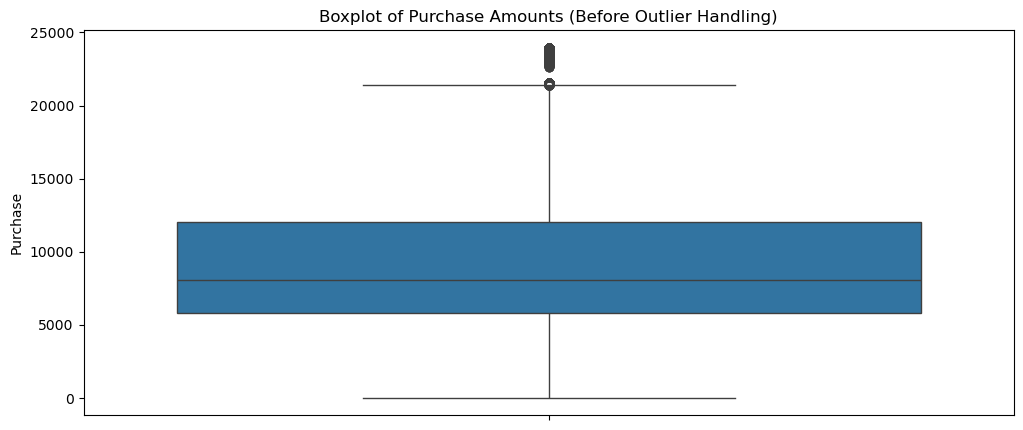

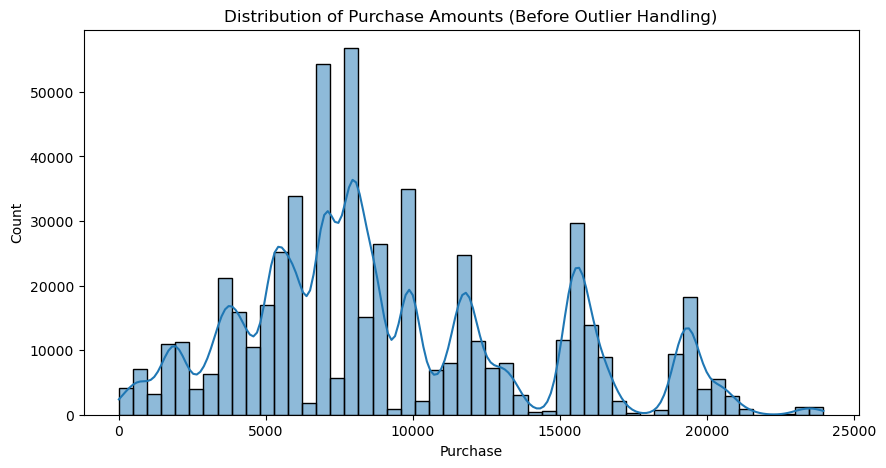

In [7]:
# Boxplot to detect outliers
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, y="Purchase")
plt.title("Boxplot of Purchase Amounts (Before Outlier Handling)")
plt.show()

# Distribution Plot Before Outlier Handling
plt.figure(figsize=(10, 5))
sns.histplot(df["Purchase"], kde=True, bins=50)
plt.title("Distribution of Purchase Amounts (Before Outlier Handling)")
plt.show()


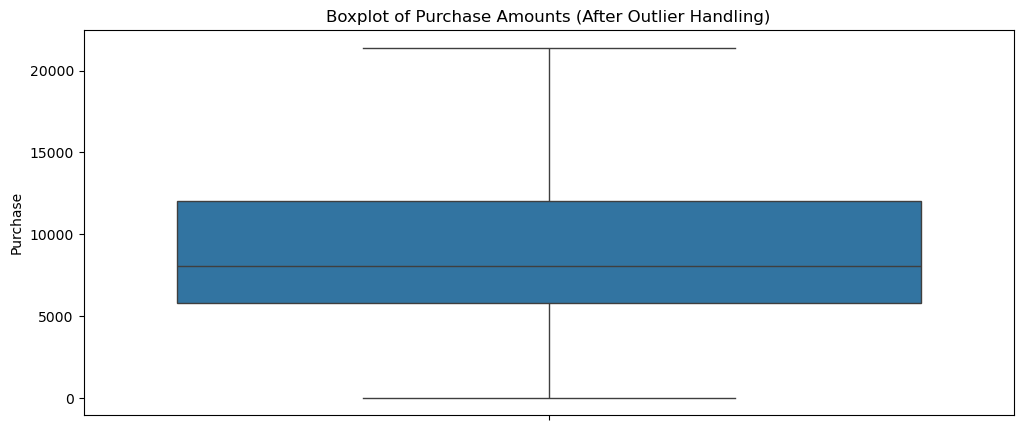

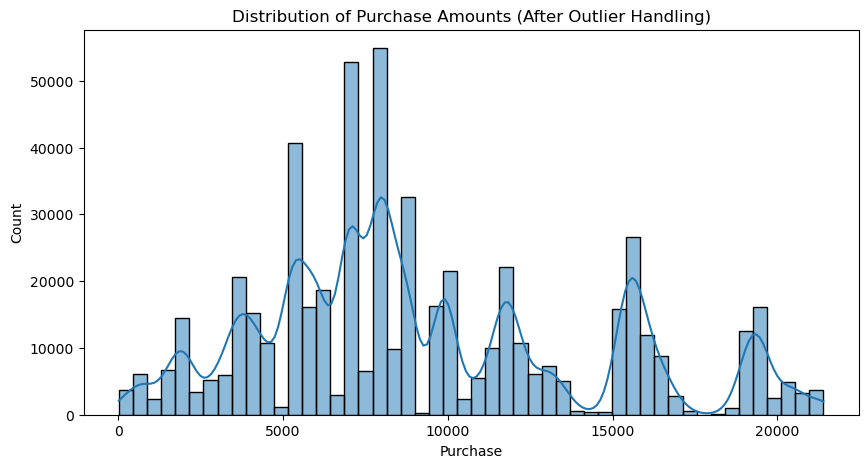

In [8]:
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

df = handle_outliers_iqr(df, "Purchase")

# Visualizing After Outlier Handling
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, y="Purchase")
plt.title("Boxplot of Purchase Amounts (After Outlier Handling)")
plt.show()

# Distribution Plot After Outlier Handling
plt.figure(figsize=(10, 5))
sns.histplot(df["Purchase"], kde=True, bins=50)
plt.title("Distribution of Purchase Amounts (After Outlier Handling)")
plt.show()

In [9]:
# Spending by Gender
gender_spending = df.groupby("Gender")["Purchase"].mean()
print("Spending by Gender:\n", gender_spending)
print()
# Spending by Age Group
age_spending = df.groupby("Age")["Purchase"].mean()
print("Spending by Age Group:\n", age_spending)
print()
# Spending by Marital Status
marital_spending = df.groupby("Marital_Status")["Purchase"].mean()
print("Spending by Marital Status:\n", marital_spending)
print()
# Spending by City
city_spending = df.groupby("City_Category")["Purchase"].mean()
print("Spending by City:\n", city_spending)
print()
# Spending by Product Category
product_spending = df.groupby("Product_Category")["Purchase"].mean()
print("Spending by Product:\n", product_spending)

Spending by Gender:
 Gender
F    8726.256327
M    9428.373455
Name: Purchase, dtype: float64

Spending by Age Group:
 Age
0-17     8925.539597
18-25    9164.189554
26-35    9244.947060
36-45    9320.888550
46-50    9198.531093
51-55    9519.560427
55+      9319.768741
Name: Purchase, dtype: float64

Spending by Marital Status:
 Marital_Status
0    9257.517959
1    9251.430702
Name: Purchase, dtype: float64

Spending by City:
 City_Category
A    8903.502451
B    9142.912942
C    9709.786528
Name: Purchase, dtype: float64

Spending by Product:
 Product_Category
1     13606.218596
2     11251.935384
3     10096.705734
4      2329.659491
5      6240.088178
6     15838.478550
7     16365.689600
8      7498.958078
9     15233.089024
10    18745.626829
11     4685.268456
12     1350.859894
13      722.400613
14    13141.625739
15    14775.791017
16    14766.037037
17    10170.759516
18     2972.864320
19       37.041797
20      370.481176
Name: Purchase, dtype: float64


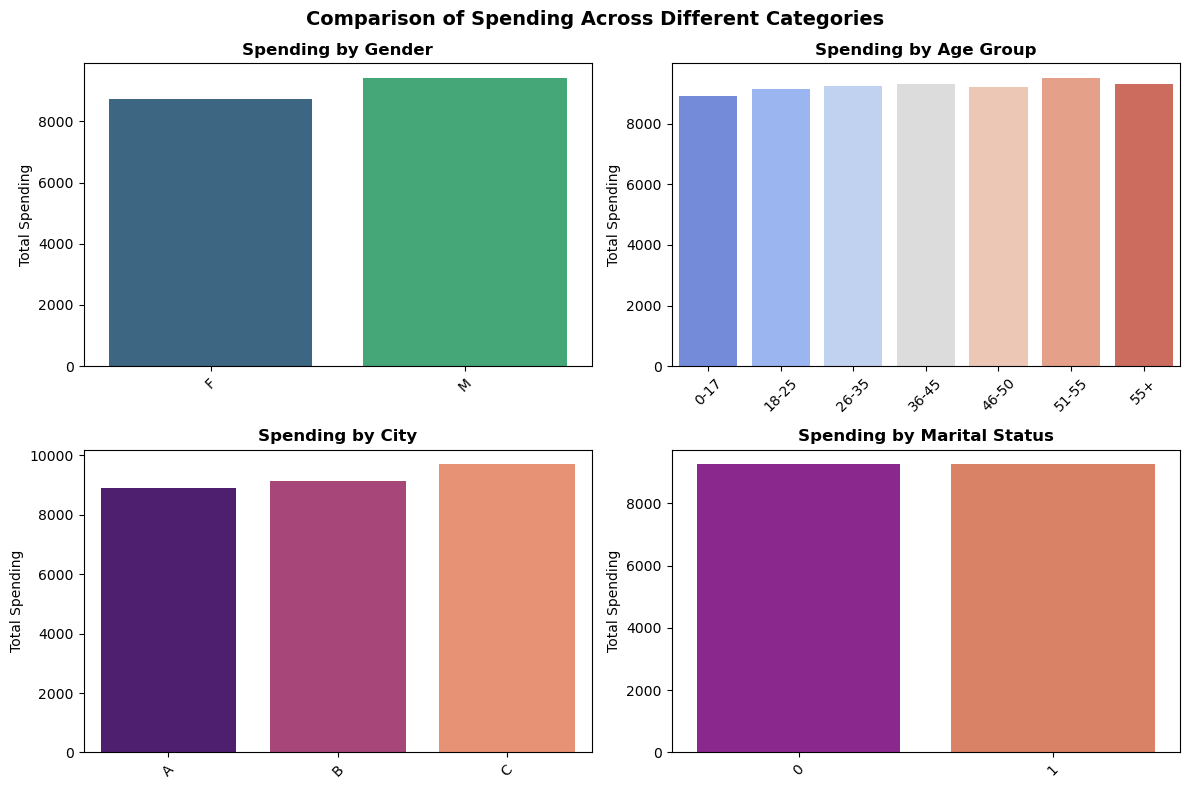

In [10]:
# Define subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Data and titles for each plot
data_sets = [gender_spending, age_spending, city_spending, marital_spending]
titles = ["Spending by Gender", "Spending by Age Group", "Spending by City", "Spending by Marital Status"]
palettes = ["viridis", "coolwarm", "magma", "plasma"]  # Distinct but visually appealing color schemes

# Loop through the axes and plot each dataset
for ax, data, title, palette in zip(axes.flat, data_sets, titles, palettes):
    sns.barplot(x=data.index, y=data.values, hue=data.index, palette=palette, legend=False, ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("")  # Remove redundant x-labels
    ax.set_ylabel("Total Spending")
    ax.tick_params(axis="x", rotation=45)  # Rotate x-axis labels for better readability

# Adjust layout and add a global title
fig.suptitle("Comparison of Spending Across Different Categories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

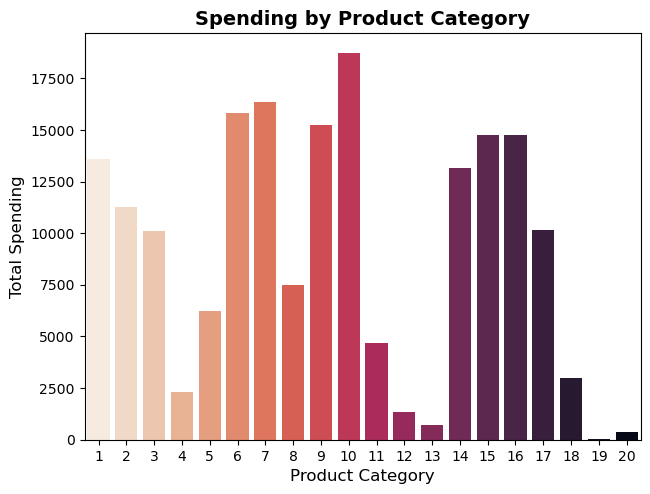

In [11]:
sns.barplot(x=product_spending.index, y=product_spending.values, hue=product_spending.index, palette="rocket_r", legend=False)
plt.tight_layout()
plt.title("Spending by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Spending", fontsize=12)
plt.show()

In [12]:
def confidence_interval(data, confidence=0.95, sample_size=1000):
    sample = np.random.choice(data, size=sample_size, replace=True)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)  # Sample standard deviation
    z_score = stats.norm.ppf((1 + confidence) / 2)  # Critical value for given confidence level
    
    margin_error = z_score * (sample_std / np.sqrt(sample_size))
    lower_bound = sample_mean - margin_error
    upper_bound = sample_mean + margin_error
    ci_width = upper_bound - lower_bound
    
    return lower_bound, upper_bound, sample_mean, ci_width


In [13]:
def confidence_interval(data, confidence=0.95, sample_size=1000):
    sample = np.random.choice(data, size=sample_size, replace=True)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)  # Sample standard deviation
    z_score = stats.norm.ppf((1 + confidence) / 2)  # Critical value for given confidence level
    
    margin_error = z_score * (sample_std / np.sqrt(sample_size))
    lower_bound = sample_mean - margin_error
    upper_bound = sample_mean + margin_error
    ci_width = upper_bound - lower_bound
    
    return lower_bound, upper_bound, sample_mean, ci_width


In [19]:
# Different sample sizes and confidence levels
sample_sizes = [100, 500, 1000, 5000, 10000]
confidence_levels = [0.90, 0.95, 0.99]

gender_ci_results = []
for sample_size in sample_sizes:
    for conf_level in confidence_levels:
        lower, upper, mean, width = confidence_interval(gender_spending, confidence=conf_level, sample_size=sample_size)
        gender_ci_results.append([sample_size, conf_level, lower, upper, mean, width])

gender_ci_df = pd.DataFrame(gender_ci_results, columns=["Sample Size", "Confidence Level", "Lower", "Upper", "Mean", "Width"])
print("Confidance Interval by Gender:")
print(gender_ci_df)
print()

age_ci_results = []
for sample_size in sample_sizes:
    for conf_level in confidence_levels:
        lower, upper, mean, width = confidence_interval(age_spending, confidence=conf_level, sample_size=sample_size)
        age_ci_results.append([sample_size, conf_level, lower, upper, mean, width])

age_ci_df = pd.DataFrame(age_ci_results, columns=["Sample Size", "Confidence Level", "Lower", "Upper", "Mean", "Width"])
print("Confidance Interval by Age Group:")
print(age_ci_df)
print()

city_ci_results = []
for sample_size in sample_sizes:
    for conf_level in confidence_levels:
        lower, upper, mean, width = confidence_interval(city_spending, confidence=conf_level, sample_size=sample_size)
        city_ci_results.append([sample_size, conf_level, lower, upper, mean, width])

city_ci_df = pd.DataFrame(city_ci_results, columns=["Sample Size", "Confidence Level", "Lower", "Upper", "Mean", "Width"])
print("Confidance Interval by City:")
print(city_ci_df)
print()

marital_ci_results = []
for sample_size in sample_sizes:
    for conf_level in confidence_levels:
        lower, upper, mean, width = confidence_interval(marital_spending, confidence=conf_level, sample_size=sample_size)
        marital_ci_results.append([sample_size, conf_level, lower, upper, mean, width])

marital_ci_df = pd.DataFrame(marital_ci_results, columns=["Sample Size", "Confidence Level", "Lower", "Upper", "Mean", "Width"])
print("Confidance Interval by Marial Status:")
print(marital_ci_df)
print()

product_ci_results = []
for sample_size in sample_sizes:
    for conf_level in confidence_levels:
        lower, upper, mean, width = confidence_interval(product_spending, confidence=conf_level, sample_size=sample_size)
        product_ci_results.append([sample_size, conf_level, lower, upper, mean, width])

product_ci_df = pd.DataFrame(product_ci_results, columns=["Sample Size", "Confidence Level", "Lower", "Upper", "Mean", "Width"])
print("Confidance Interval by Product:")
print(product_ci_df)

Confidance Interval by Gender:
    Sample Size  Confidence Level        Lower        Upper         Mean  \
0           100              0.90  9068.999747  9183.926432  9126.463090   
1           100              0.95  8966.534722  9103.841004  9035.187863   
2           100              0.99  9014.808619  9195.990533  9105.399576   
3           500              0.90  9065.528159  9117.186308  9091.357233   
4           500              0.95  9029.697692  9091.230467  9060.464080   
5           500              0.99  9034.027170  9114.985675  9074.506422   
6          1000              0.90  9038.714858  9075.192131  9056.953494   
7          1000              0.95  9058.354733  9101.891985  9080.123359   
8          1000              0.99  9035.385589  9092.563741  9063.974665   
9          5000              0.90  9075.327736  9091.659307  9083.493522   
10         5000              0.95  9072.218070  9091.679657  9081.948864   
11         5000              0.99  9066.631928  9092.2105

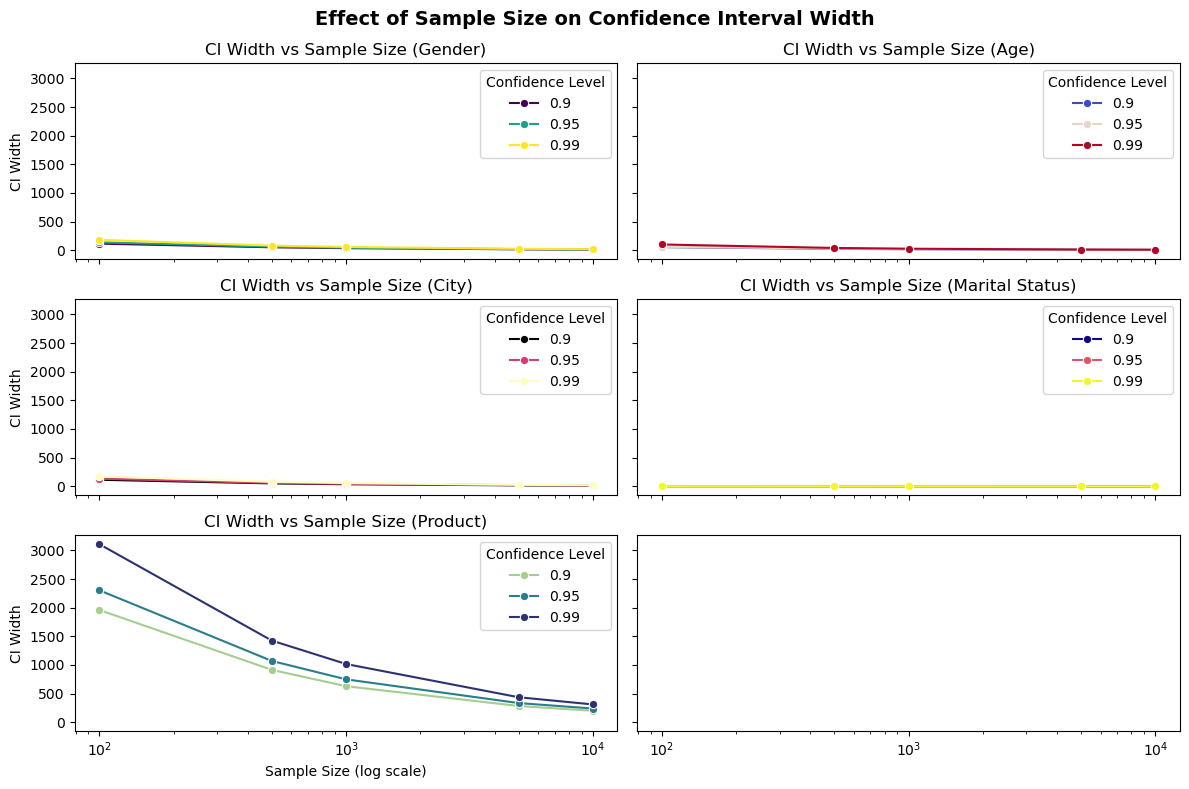

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)

# CI width vs. Sample size plots for different groupings
ci_dfs = [gender_ci_df, age_ci_df, city_ci_df, marital_ci_df,product_ci_df]
titles = ["Gender", "Age", "City", "Marital Status","Product"]
palettes = ["viridis", "coolwarm", "magma", "plasma","crest"]  # Keeping diverse but distinct palettes

for ax, ci_df, title, palette in zip(axes.flat, ci_dfs, titles, palettes):
    sns.lineplot(data=ci_df, x="Sample Size", y="Width", hue="Confidence Level", marker="o", palette=palette, ax=ax)
    ax.set_xscale("log")  # Log scale for better visualization
    ax.set_title(f"CI Width vs Sample Size ({title})")  # Subplot-specific title
    ax.set_xlabel("Sample Size (log scale)")
    ax.set_ylabel("CI Width")
    ax.legend(title="Confidence Level", loc="upper right")  # Per subplot legend

# Overall figure title
fig.suptitle("Effect of Sample Size on Confidence Interval Width", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


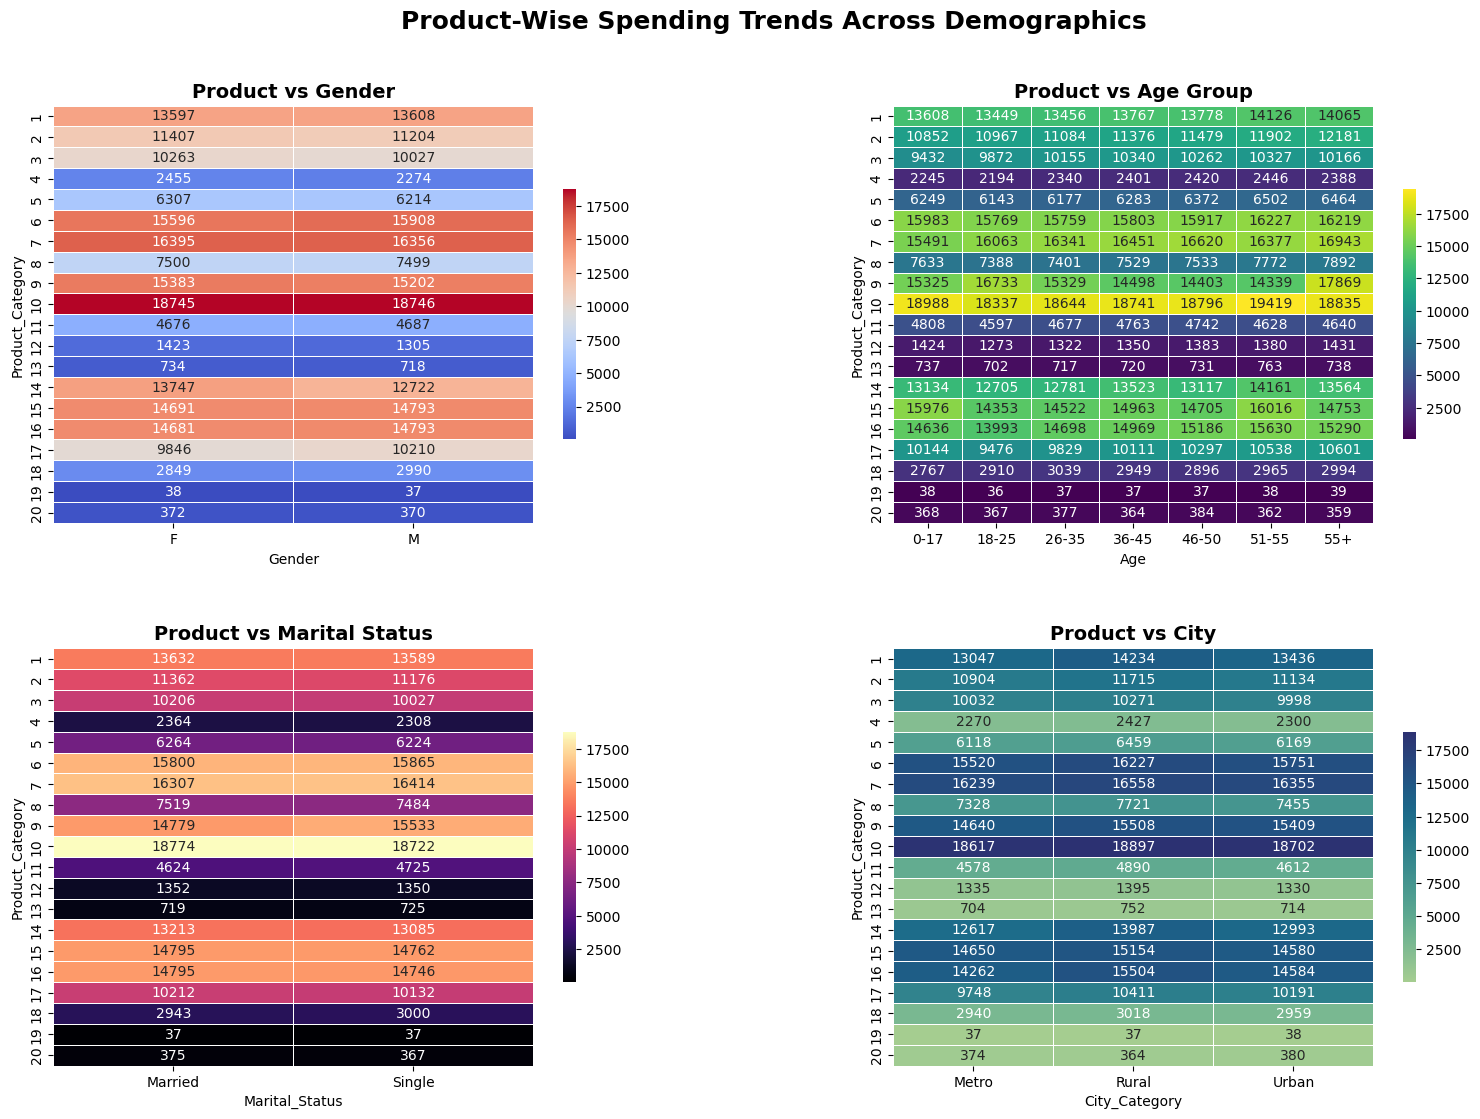

In [17]:
# Replace category labels for better readability
df["Marital_Status"] = df["Marital_Status"].replace({0: "Single", 1: "Married"})
df["City_Category"] = df["City_Category"].replace({"A": "Metro", "B": "Urban", "C": "Rural"})

# Compute average purchase per category
grouped_data = {
    "Gender": df.groupby(["Product_Category", "Gender"])["Purchase"].mean().unstack(),
    "Age Group": df.groupby(["Product_Category", "Age"])["Purchase"].mean().unstack(),
    "Marital Status": df.groupby(["Product_Category", "Marital_Status"])["Purchase"].mean().unstack(),
    "City": df.groupby(["Product_Category", "City_Category"])["Purchase"].mean().unstack()
}

# Initialize figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define color palettes
palettes = ["coolwarm", "viridis", "magma", "crest"]

# Create heatmaps with improved axis formatting
for i, ((title, data), cmap) in enumerate(zip(grouped_data.items(), palettes)):
    ax = axes[i // 2, i % 2]  # Get subplot position
    heatmap = sns.heatmap(
        data, cmap=cmap, annot=True, fmt=".0f", linewidths=0.5, ax=ax, cbar=True,
        cbar_kws={"shrink": 0.6}
    )
    
    ax.set_title(f"Product vs {title}", fontsize=14, fontweight="bold")

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, hspace=0.3, wspace=0.4)
plt.suptitle("Product-Wise Spending Trends Across Demographics", fontsize=18, fontweight="bold")

plt.show()
